<a href="https://colab.research.google.com/github/sayandwip2004ghosh/DSA_LEETCODEGFG/blob/main/synckneekljsw_calculate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Install & Import
# ============================================================
!pip install tensorflow pillow matplotlib numpy pandas --quiet

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import json
from PIL import Image
from pathlib import Path

print("✅ All imports successful!")
print(f"   TensorFlow version: {tf.__version__}")

✅ All imports successful!
   TensorFlow version: 2.19.0


In [ ]:
# ============================================================
# CELL 2: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [ ]:
# ============================================================
# CELL 3: KL/JSW Reference Table
# Sources:
#   Literature mm values : Ratzlaff 2018, OARSI 2014, PMC2692745
#   Dataset pixel stats  : your joint_space_2.csv (n=3900 images)
# ============================================================

KL_JSW_REFERENCE = {
    0: {
        "name": "Grade 0 — Normal",
        "description": "No pathological features. Normal joint space.",
        "features": ["No osteophytes", "No joint space narrowing", "Normal bone contours"],
        # ── Literature mm values ─────────────────────────────
        "medial_jsw_mm":  {"min": 4.8, "mean": 5.7, "max": 7.0},
        "lateral_jsw_mm": {"min": 5.2, "mean": 6.3, "max": 8.0},
        # ── Your dataset pixel stats (n=999 images) ──────────
        "dataset_px": {"n": 999, "mean_px": 24.4, "median_px": 12.0,
                       "p25_px": 10.0, "p75_px": 24.0},
        "jsn_grade": "None",
        "severity":  "Normal",
        "color":     "#27ae60",
        "clinical_notes": "No osteoarthritis. Normal cartilage thickness.",
        "references": "Ratzlaff 2018; OARSI 2014; your dataset n=999"
    },
    1: {
        "name": "Grade 1 — Doubtful",
        "description": "Doubtful narrowing of joint space with possible osteophytic lipping.",
        "features": ["Possible osteophyte lipping", "Doubtful JSN", "Subchondral bone normal"],
        "medial_jsw_mm":  {"min": 3.8, "mean": 4.8, "max": 6.2},
        "lateral_jsw_mm": {"min": 4.3, "mean": 5.5, "max": 6.8},
        "dataset_px": {"n": 999, "mean_px": 23.2, "median_px": 12.0,
                       "p25_px": 9.0, "p75_px": 22.0},
        "jsn_grade": "Grade 0-1 (OARSI)",
        "severity":  "Minimal/Doubtful OA",
        "color":     "#f39c12",
        "clinical_notes": "Pre-OA state. Annual JSW loss ~0.06–0.18 mm.",
        "references": "Ratzlaff 2018; PMC8546160; your dataset n=999"
    },
    2: {
        "name": "Grade 2 — Mild OA",
        "description": "Definite osteophytes with possible narrowing of joint space.",
        "features": ["Definite osteophytes", "Possible JSN", "No sclerosis"],
        "medial_jsw_mm":  {"min": 3.0, "mean": 4.2, "max": 5.5},
        "lateral_jsw_mm": {"min": 3.8, "mean": 4.8, "max": 6.0},
        "dataset_px": {"n": 989, "mean_px": 25.0, "median_px": 12.0,
                       "p25_px": 9.0, "p75_px": 26.0},
        "jsn_grade": "Grade 1 (OARSI)",
        "severity":  "Mild OA",
        "color":     "#e67e22",
        "clinical_notes": "Radiographic OA threshold (KL ≥2). Mean JSW ~4.2 mm.",
        "references": "Ratzlaff 2018; OARSI 2014; your dataset n=989"
    },
    3: {
        "name": "Grade 3 — Moderate OA",
        "description": "Definite narrowing, moderate osteophytes, sclerosis, possible bone deformity.",
        "features": ["Definite JSN", "Moderate osteophytes",
                     "Subchondral sclerosis", "Possible bone deformity"],
        "medial_jsw_mm":  {"min": 1.5, "mean": 2.8, "max": 4.0},
        "lateral_jsw_mm": {"min": 2.5, "mean": 3.7, "max": 5.0},
        "dataset_px": {"n": 745, "mean_px": 27.1, "median_px": 12.0,
                       "p25_px": 10.0, "p75_px": 31.0},
        "jsn_grade": "Grade 2 (OARSI)",
        "severity":  "Moderate OA",
        "color":     "#e74c3c",
        "clinical_notes": "Significant JSN. Annual loss ~0.75 mm/yr (KL2→3 transition).",
        "references": "Ratzlaff 2018; PMC2692745; your dataset n=745"
    },
    4: {
        "name": "Grade 4 — Severe OA",
        "description": "Large osteophytes, marked narrowing, severe sclerosis, near bone-on-bone.",
        "features": ["Large osteophytes", "Marked/severe JSN",
                     "Severe sclerosis", "Bone deformity", "Near bone-on-bone"],
        "medial_jsw_mm":  {"min": 0.0, "mean": 1.2, "max": 2.5},
        "lateral_jsw_mm": {"min": 1.0, "mean": 2.5, "max": 4.0},
        "dataset_px": {"n": 168, "mean_px": 29.7, "median_px": 13.0,
                       "p25_px": 11.0, "p75_px": 40.0},
        "jsn_grade": "Grade 3 (OARSI)",
        "severity":  "Severe OA",
        "color":     "#8e44ad",
        "clinical_notes": "Bone-on-bone possible. JSW <2 mm → arthroplasty evaluation.",
        "references": "OARSI 2014; your dataset n=168"
    }
}

print("✅ KL/JSW reference table loaded!")
print(f"\n{'KL':>3}  {'Severity':<22}  {'Medial mean':>11}  {'Dataset N':>10}  {'px p75':>7}")
print("-"*60)
for g, d in KL_JSW_REFERENCE.items():
    print(f"  {g}  {d['severity']:<22}  "
          f"{d['medial_jsw_mm']['mean']:>8.1f} mm  "
          f"{d['dataset_px']['n']:>10}  "
          f"{d['dataset_px']['p75_px']:>6.1f}px")

✅ KL/JSW reference table loaded!

 KL  Severity                Medial mean   Dataset N   px p75
------------------------------------------------------------
  0  Normal                       5.7 mm         999    24.0px
  1  Minimal/Doubtful OA          4.8 mm         999    22.0px
  2  Mild OA                      4.2 mm         989    26.0px
  3  Moderate OA                  2.8 mm         745    31.0px
  4  Severe OA                    1.2 mm         168    40.0px


Dataset summary:
  KL 0: 999 images
  KL 1: 999 images
  KL 2: 989 images
  KL 3: 745 images
  KL 4: 168 images


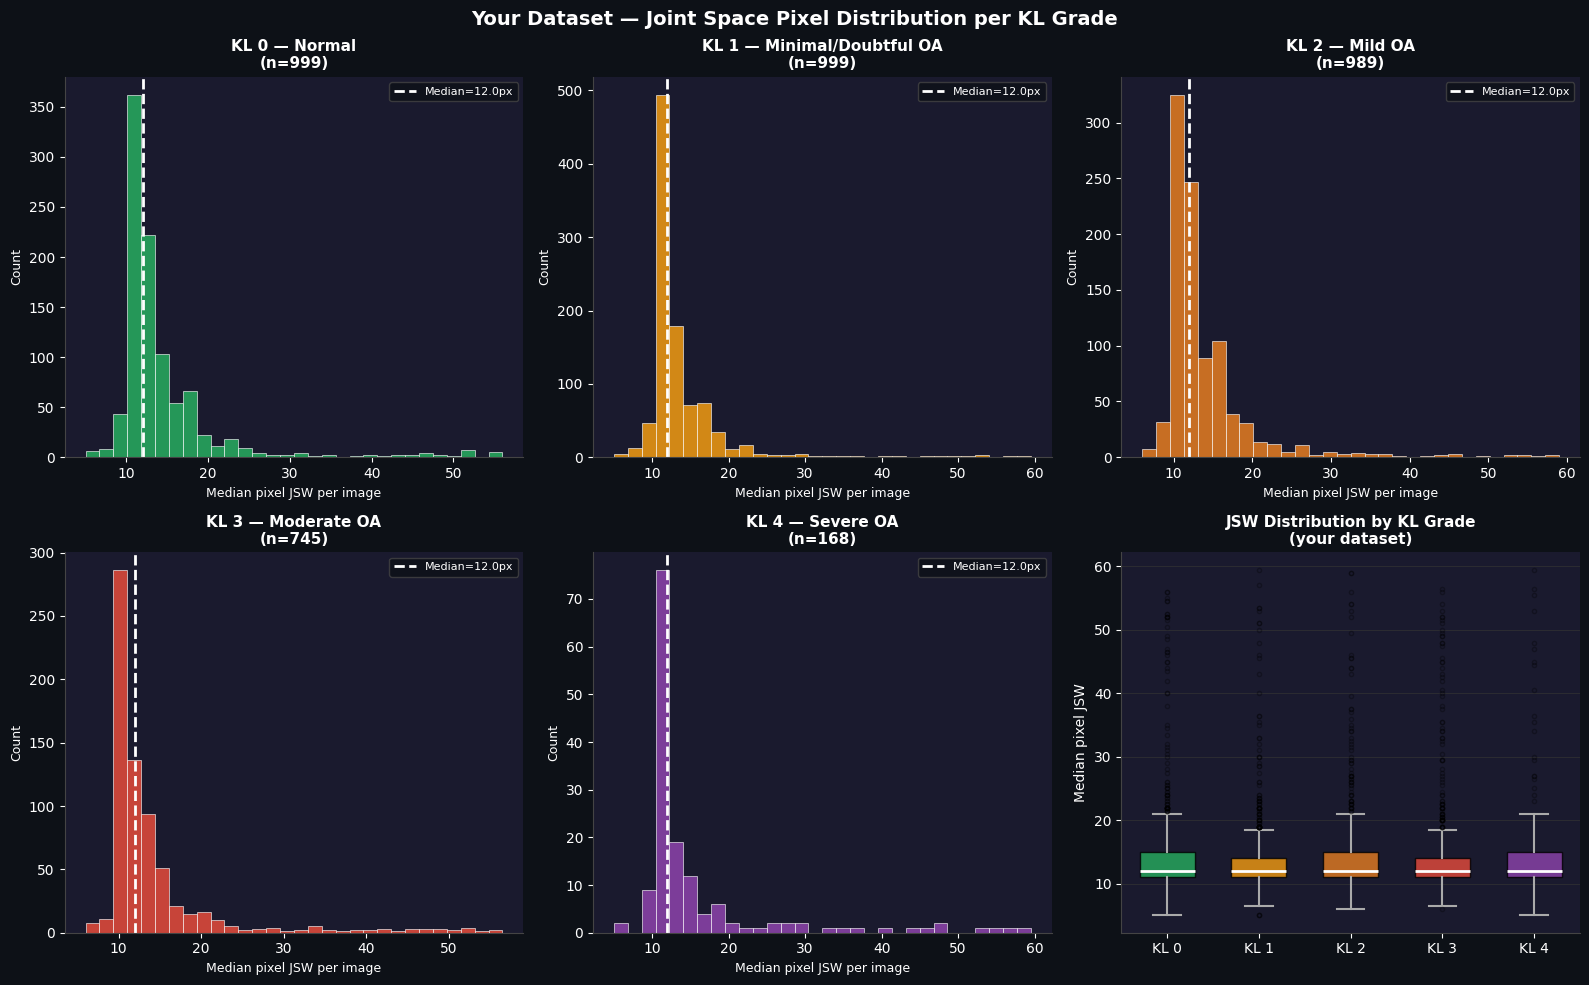

📊 Saved as 'dataset_jsw_distribution.png'

DATASET JSW PIXEL STATS (non-zero points, median per image)
 KL      N     Mean     Std     p25   Median     p75     p95
-----------------------------------------------------------------
  0    999     16.7    15.0    11.0     12.0    15.5    46.5
  1    999     14.9    10.8    11.0     12.0    14.5    24.0
  2    989     17.0    16.1    11.0     12.0    15.0    44.0
  3    745     19.4    21.3    11.0     12.0    15.0    77.4
  4    168     24.1    26.1    11.0     12.0    18.0    95.0

Note: Values in pixels. The 56 profile points span the full image width.
Large values (>50px) are boundary artifacts — p75 trend is the true signal.


In [ ]:
# ============================================================
# CELL 3b: Explore your dataset's JSW pixel distributions
# Run AFTER Cell 2 (drive mount) — reads the CSVs directly
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Paths — update if needed ─────────────────────────────────
JS_CSV  = "/content/drive/MyDrive/ (4)jsw with kl fatsam data/kl grade csv jsw (2)/joint_space 2.csv"
UE_CSV  = "/content/drive/MyDrive/ (4)jsw with kl fatsam data/kl grade csv jsw (2)/upper_edge 2.csv"
LE_CSV  = "/content/drive/MyDrive/ (4)jsw with kl fatsam data/kl grade csv jsw (2)/lower_edge 2.csv"
# ─────────────────────────────────────────────────────────────

js = pd.read_csv(JS_CSV)
ue = pd.read_csv(UE_CSV)
le = pd.read_csv(LE_CSV)

point_cols = [f"Point_{i}" for i in range(1, 57)]
js_vals    = js[point_cols].values.astype(float)
grades     = js["Grade"].values

COLORS = {0:"#27ae60", 1:"#f39c12", 2:"#e67e22", 3:"#e74c3c", 4:"#8e44ad"}
GRADE_COUNTS = {g: int((grades==g).sum()) for g in range(5)}

print("Dataset summary:")
for g in range(5):
    print(f"  KL {g}: {GRADE_COUNTS[g]} images")

# ── Per-image: median of non-zero pixel gap ─────────────────
def img_jsw_px(vals, g_mask):
    out = []
    for row in vals[g_mask]:
        nz = row[row > 0]
        out.append(np.median(nz) if len(nz) >= 5 else np.nan)
    return np.array(out)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

# ── Plot 1-5: per-grade histogram ────────────────────────────
for g in range(5):
    ax = axes[g]
    ax.set_facecolor('#1a1a2e')
    vals_g = img_jsw_px(js_vals, grades==g)
    vals_g = vals_g[~np.isnan(vals_g)]
    vals_g = vals_g[vals_g <= 60]     # clip outliers for display
    ax.hist(vals_g, bins=30, color=COLORS[g], edgecolor='white',
            linewidth=0.5, alpha=0.85)
    ax.axvline(np.median(vals_g), color='white', linewidth=2,
               linestyle='--', label=f'Median={np.median(vals_g):.1f}px')
    ax.set_title(f"KL {g} — {KL_JSW_REFERENCE[g]['severity']}\n(n={GRADE_COUNTS[g]})",
                 color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Median pixel JSW per image', color='white', fontsize=9)
    ax.set_ylabel('Count', color='white', fontsize=9)
    ax.tick_params(colors='white')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#444')
    ax.legend(facecolor='#0d1117', edgecolor='#444', labelcolor='white', fontsize=8)

# ── Plot 6: overlay box plot all grades ─────────────────────
ax = axes[5]
ax.set_facecolor('#1a1a2e')
data_by_grade = []
for g in range(5):
    v = img_jsw_px(js_vals, grades==g)
    v = v[~np.isnan(v)]
    v = v[v <= 60]
    data_by_grade.append(v)

bp = ax.boxplot(data_by_grade, patch_artist=True, widths=0.6,
                medianprops=dict(color='white', linewidth=2))
for patch, g in zip(bp['boxes'], range(5)):
    patch.set_facecolor(COLORS[g])
    patch.set_alpha(0.8)
for whisker in bp['whiskers']: whisker.set(color='#aaa', linewidth=1.5)
for cap     in bp['caps']:     cap.set(color='#aaa',     linewidth=1.5)
for flier   in bp['fliers']:   flier.set(marker='o', color='#aaa', alpha=0.3, markersize=3)

ax.set_xticklabels([f'KL {g}' for g in range(5)], color='white', fontsize=10)
ax.set_ylabel('Median pixel JSW', color='white', fontsize=10)
ax.set_title('JSW Distribution by KL Grade\n(your dataset)', color='white',
             fontsize=11, fontweight='bold')
ax.tick_params(colors='white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#444')
ax.yaxis.grid(True, color='#333', linewidth=0.5)
ax.set_axisbelow(True)

plt.suptitle('Your Dataset — Joint Space Pixel Distribution per KL Grade',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_jsw_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("📊 Saved as 'dataset_jsw_distribution.png'")


# ── Text summary ─────────────────────────────────────────────
print("\n" + "="*65)
print("DATASET JSW PIXEL STATS (non-zero points, median per image)")
print("="*65)
print(f"{'KL':>3}  {'N':>5}  {'Mean':>7}  {'Std':>6}  {'p25':>6}  "
      f"{'Median':>7}  {'p75':>6}  {'p95':>6}")
print("-"*65)
for g in range(5):
    v = img_jsw_px(js_vals, grades==g)
    v = v[~np.isnan(v)]
    print(f"  {g}  {len(v):>5}  {v.mean():>7.1f}  {v.std():>6.1f}  "
          f"{np.percentile(v,25):>6.1f}  {np.median(v):>7.1f}  "
          f"{np.percentile(v,75):>6.1f}  {np.percentile(v,95):>6.1f}")

print("\nNote: Values in pixels. The 56 profile points span the full image width.")
print("Large values (>50px) are boundary artifacts — p75 trend is the true signal.")

In [ ]:
# ============================================================
# CELL 5: Preprocessing + Classification (with dataset JSW)
# ============================================================
from tensorflow.keras.applications.inception_v3 import preprocess_input

def preprocess_image(image_path: str, target_size: tuple) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size, Image.LANCZOS)
    x   = np.array(img, dtype=np.float32)
    x   = np.expand_dims(x, axis=0)
    x   = preprocess_input(x)
    return x


def classify_kl_grade_keras(image_path: str) -> dict:
    if keras_model is None:
        return {"kl_grade": -1, "reasoning": "Model not loaded."}
    if not Path(image_path).exists():
        return {"kl_grade": -1, "reasoning": f"File not found: {image_path}"}
    try:
        x     = preprocess_image(image_path, TARGET_SIZE)
        preds = keras_model.predict(x, verbose=0)

        kl_grade   = int(np.argmax(preds, axis=1)[0])
        conf_score = float(np.max(preds, axis=1)[0])
        kl_grade   = max(0, min(4, kl_grade))

        confidence = ("High"     if conf_score > 0.8 else
                      "Moderate" if conf_score > 0.5 else "Low")

        feat_map = {
            0: ("None",     "None",     "None",     "None"),
            1: ("Possible", "Doubtful", "None",     "None"),
            2: ("Definite", "Possible", "None",     "None"),
            3: ("Moderate", "Definite", "Moderate", "Possible"),
            4: ("Large",    "Marked",   "Severe",   "Definite"),
        }
        osteophytes, jsn, sclerosis, bone_def = feat_map[kl_grade]
        ref = KL_JSW_REFERENCE[kl_grade]
        px  = ref["dataset_px"]

        return {
            "kl_grade":              kl_grade,
            "confidence":            confidence,
            "confidence_score":      round(conf_score, 4),
            "raw_predictions":       preds[0].tolist(),
            "osteophytes":           osteophytes,
            "joint_space_narrowing": jsn,
            "sclerosis":             sclerosis,
            "bone_deformity":        bone_def,
            "compartment_affected":  "Both (inferred from KL grade)",
            # ── dataset-backed pixel context ──────────────────
            "dataset_jsw_note":      (f"Dataset median={px['median_px']}px  "
                                      f"p25={px['p25_px']}px  p75={px['p75_px']}px  "
                                      f"(n={px['n']} training images)"),
            "reasoning":             ref["description"] + f" (KL {kl_grade}, conf {conf_score:.2f})",
            "treatment_suggestion":  ref["clinical_notes"],
        }
    except Exception as e:
        return {"kl_grade": -1, "reasoning": f"Prediction error: {e}"}


def get_jsw_estimate(kl_grade: int) -> dict:
    return KL_JSW_REFERENCE.get(kl_grade, {})


print("✅ Classification functions ready!")

✅ Classification functions ready!


In [ ]:
# ============================================================
# CELL 6: Text Report Printer
# ============================================================

def print_report(classification: dict, jsw_data: dict):
    kl  = classification.get("kl_grade", -1)
    med = jsw_data.get("medial_jsw_mm", {})
    lat = jsw_data.get("lateral_jsw_mm", {})

    print("\n" + "═"*62)
    print("   KNEE OA ANALYSIS REPORT")
    print("═"*62)
    print(f"  KL Grade       : {kl} — {jsw_data.get('name','N/A')}")
    print(f"  Severity       : {jsw_data.get('severity','N/A')}")
    print(f"  Confidence     : {classification.get('confidence','N/A')}  "
          f"(score: {classification.get('confidence_score','N/A')})")
    print(f"  Raw pred vec   : {classification.get('raw_predictions','N/A')}")
    print()
    print("  ┌──────────────────────────────────────────────────┐")
    print("  │     ESTIMATED JOINT SPACE WIDTH (literature)     │")
    print("  ├──────────────────────────────────────────────────┤")
    print(f"  │  Medial   : {med.get('mean','?')} mm  "
          f"(range {med.get('min','?')}–{med.get('max','?')} mm)        │")
    print(f"  │  Lateral  : {lat.get('mean','?')} mm  "
          f"(range {lat.get('min','?')}–{lat.get('max','?')} mm)        │")
    print("  └──────────────────────────────────────────────────┘")
    print()
    print("  Radiological Features:")
    print(f"    • Osteophytes     : {classification.get('osteophytes','N/A')}")
    print(f"    • JSN             : {classification.get('joint_space_narrowing','N/A')}")
    print(f"    • Sclerosis       : {classification.get('sclerosis','N/A')}")
    print(f"    • Bone deformity  : {classification.get('bone_deformity','N/A')}")
    print(f"    • Compartment     : {classification.get('compartment_affected','N/A')}")
    print()
    print(f"  Clinical Notes : {jsw_data.get('clinical_notes','')}")
    print(f"  AI Reasoning   : {classification.get('reasoning','')}")
    print(f"  References     : {jsw_data.get('references','')}")
    print("═"*62)
    print("  ⚠️  For clinical review by qualified professionals only.")
    print("═"*62)


print("✅ Report function ready!")

✅ Report function ready!


In [ ]:
# ============================================================
# CELL 7: Visualization (3-panel figure + reference chart)
# ============================================================

def display_results(image_path: str, classification: dict, jsw_data: dict):
    kl          = classification.get("kl_grade", -1)
    grade_color = jsw_data.get("color", "#888888")
    med         = jsw_data.get("medial_jsw_mm", {})
    lat         = jsw_data.get("lateral_jsw_mm", {})

    fig = plt.figure(figsize=(18, 10))
    fig.patch.set_facecolor('#0d1117')

    # ── Panel 1: X-ray ──────────────────────────────────────
    ax1 = fig.add_subplot(1, 3, 1)
    img = Image.open(image_path)
    ax1.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax1.set_title("Input X-ray", color='white', fontsize=13, fontweight='bold', pad=10)
    ax1.axis('off')
    ax1.set_facecolor('#1a1a2e')
    rect = plt.Rectangle((0,0),1,1, transform=ax1.transAxes,
                          fill=False, edgecolor=grade_color, linewidth=4)
    ax1.add_patch(rect)

    # ── Panel 2: Classification result ──────────────────────
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.set_facecolor('#1a1a2e')
    ax2.axis('off')

    circle = plt.Circle((0.5, 0.78), 0.16, color=grade_color, zorder=5)
    ax2.add_patch(circle)
    ax2.text(0.5, 0.78, str(kl), ha='center', va='center',
             fontsize=36, fontweight='bold', color='white', zorder=6,
             transform=ax2.transAxes)
    ax2.text(0.5, 0.95, 'KL GRADE', ha='center', fontsize=11,
             color='#aaaaaa', transform=ax2.transAxes, fontweight='bold')
    ax2.text(0.5, 0.60, jsw_data.get('name',''), ha='center',
             fontsize=12, color=grade_color, transform=ax2.transAxes, fontweight='bold')
    ax2.text(0.5, 0.54, f"Confidence: {classification.get('confidence','N/A')}  "
             f"({classification.get('confidence_score',''):.2f})",
             ha='center', fontsize=10, color='#cccccc', transform=ax2.transAxes)

    jsw_text = (
        f"━━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"ESTIMATED JOINT SPACE WIDTH\n"
        f"━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
        f"Medial:  {med.get('mean','?')} mm  ({med.get('min','?')}–{med.get('max','?')} mm)\n"
        f"Lateral: {lat.get('mean','?')} mm  ({lat.get('min','?')}–{lat.get('max','?')} mm)\n\n"
        f"Severity : {jsw_data.get('severity','N/A')}\n"
        f"OARSI JSN: {jsw_data.get('jsn_grade','N/A')}"
    )
    ax2.text(0.05, 0.46, jsw_text, ha='left', va='top', fontsize=9.5,
             color='white', transform=ax2.transAxes, fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#0d1117',
                       edgecolor=grade_color, alpha=0.9))

    features_text = "\n".join([f"  • {f}" for f in jsw_data.get('features', [])])
    ax2.text(0.05, 0.14, f"Radiological Findings:\n{features_text}",
             ha='left', va='top', fontsize=9, color='#aaaaaa', transform=ax2.transAxes)
    ax2.set_title('Classification Result', color='white', fontsize=13, fontweight='bold', pad=10)

    # ── Panel 3: JSW bar chart ───────────────────────────────
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.set_facecolor('#1a1a2e')

    grades = [0, 1, 2, 3, 4]
    x      = np.array(grades)
    width  = 0.35
    colors = [KL_JSW_REFERENCE[g]['color'] for g in grades]
    m_means = [KL_JSW_REFERENCE[g]['medial_jsw_mm']['mean']  for g in grades]
    l_means = [KL_JSW_REFERENCE[g]['lateral_jsw_mm']['mean'] for g in grades]

    ax3.bar(x - width/2, m_means, width, label='Medial JSW',
            color=[c+'cc' for c in colors], edgecolor='white', linewidth=0.5)
    ax3.bar(x + width/2, l_means, width, label='Lateral JSW',
            color=[c+'77' for c in colors], edgecolor='white', linewidth=0.5)

    ax3.errorbar(x - width/2, m_means,
                 yerr=[[m - KL_JSW_REFERENCE[g]['medial_jsw_mm']['min']  for g,m in zip(grades,m_means)],
                       [KL_JSW_REFERENCE[g]['medial_jsw_mm']['max'] - m  for g,m in zip(grades,m_means)]],
                 fmt='none', color='white', capsize=4, linewidth=1.5)
    ax3.errorbar(x + width/2, l_means,
                 yerr=[[m - KL_JSW_REFERENCE[g]['lateral_jsw_mm']['min'] for g,m in zip(grades,l_means)],
                       [KL_JSW_REFERENCE[g]['lateral_jsw_mm']['max'] - m for g,m in zip(grades,l_means)]],
                 fmt='none', color='#aaaaaa', capsize=4, linewidth=1.5)

    if kl in grades:
        ax3.axvspan(kl - 0.5, kl + 0.5, color=grade_color, alpha=0.15, zorder=0)
        ax3.axvline(kl, color=grade_color, linewidth=2, linestyle='--', alpha=0.8)

    ax3.axhline(2.0, color='#ff6b6b', linewidth=1.5, linestyle=':', alpha=0.8)
    ax3.text(4.4, 2.1, '2mm threshold\n(arthroplasty)', fontsize=7.5,
             color='#ff6b6b', ha='right')
    ax3.set_xlabel('KL Grade', color='white', fontsize=11)
    ax3.set_ylabel('JSW (mm)', color='white', fontsize=11)
    ax3.set_title('JSW by KL Grade (Literature)', color='white', fontsize=12,
                  fontweight='bold', pad=10)
    ax3.set_xticks(grades)
    ax3.set_xticklabels([f'KL {g}' for g in grades], color='white', fontsize=10)
    ax3.tick_params(colors='white')
    for spine in ['top','right']: ax3.spines[spine].set_visible(False)
    for spine in ['bottom','left']: ax3.spines[spine].set_color('#444444')
    ax3.set_ylim(0, 9)
    ax3.yaxis.grid(True, color='#333333', linewidth=0.5)
    ax3.set_axisbelow(True)
    ax3.legend(loc='upper right', facecolor='#0d1117', edgecolor='#444444',
               labelcolor='white', fontsize=9)

    reasoning = classification.get('reasoning', '')
    fig.text(0.5, 0.01, f"AI Reasoning: {reasoning}",
             ha='center', fontsize=9, color='#888888', style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e', edgecolor='#333333'))

    plt.suptitle('Knee Osteoarthritis — KL Grade & JSW Analysis',
                 color='white', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout(pad=2.0)
    plt.savefig('kl_jsw_result.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print("📊 Saved as 'kl_jsw_result.png'")


def plot_jsw_reference_chart():
    """Standalone reference chart — all grades, both compartments."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#0d1117')
    grades = [0, 1, 2, 3, 4]
    colors = [KL_JSW_REFERENCE[g]['color'] for g in grades]
    names  = [f"KL {g}" for g in grades]

    for ax, (compartment, key) in zip(axes, [("Medial","medial_jsw_mm"),
                                              ("Lateral","lateral_jsw_mm")]):
        ax.set_facecolor('#1a1a2e')
        means = [KL_JSW_REFERENCE[g][key]['mean'] for g in grades]
        mins_ = [KL_JSW_REFERENCE[g][key]['min']  for g in grades]
        maxs_ = [KL_JSW_REFERENCE[g][key]['max']  for g in grades]
        bars  = ax.bar(names, means, color=colors, edgecolor='white', linewidth=0.8, width=0.6)
        ax.errorbar(names, means,
                    yerr=[[m-mn for m,mn in zip(means,mins_)],
                          [mx-m for m,mx in zip(means,maxs_)]],
                    fmt='none', color='white', capsize=6, linewidth=2)
        for bar, mean, mx in zip(bars, means, maxs_):
            ax.text(bar.get_x()+bar.get_width()/2, mean+(mx-mean)+0.2,
                    f'{mean}mm', ha='center', color='white', fontsize=10, fontweight='bold')
        ax.axhline(2.0, color='#ff6b6b', linewidth=2, linestyle='--', alpha=0.9)
        ax.text(2.0, 2.2, 'Arthroplasty threshold', fontsize=8, color='#ff6b6b', ha='center')
        ax.set_title(f'{compartment} JSW by KL Grade', color='white',
                     fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel('JSW (mm)', color='white', fontsize=11)
        ax.set_ylim(0, 10)
        ax.tick_params(colors='white')
        for s in ['top','right']: ax.spines[s].set_visible(False)
        for s in ['bottom','left']: ax.spines[s].set_color('#444444')
        ax.yaxis.grid(True, color='#333333', linewidth=0.5)
        ax.set_axisbelow(True)
        for t in ax.get_xticklabels(): t.set_color('white')

    patches = [mpatches.Patch(color=KL_JSW_REFERENCE[g]['color'],
               label=f"KL {g}: {KL_JSW_REFERENCE[g]['severity']}") for g in grades]
    fig.legend(handles=patches, loc='lower center', ncol=5,
               facecolor='#1a1a2e', edgecolor='#444444', labelcolor='white',
               fontsize=9, bbox_to_anchor=(0.5, -0.05))
    plt.suptitle('Knee JSW Reference (OAI, OARSI & Clinical Literature)',
                 color='white', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('jsw_reference_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print("📊 Saved as 'jsw_reference_chart.png'")


print("✅ Visualization functions ready!")

✅ Visualization functions ready!


In [ ]:
# ============================================================
# CELL 8: Main Pipeline  (image → classify → report → plot)
# ============================================================

def analyze_knee_xray(image_path: str):
    """
    Full pipeline for a single X-ray:
      1. Keras model  → KL grade
      2. JSW lookup   → clinical reference values
      3. Print report
      4. Display 3-panel figure
    """
    print(f"\n{'═'*55}")
    print(f"  Analyzing: {Path(image_path).name}")
    print(f"{'═'*55}")

    if not Path(image_path).exists():
        print(f"❌ File not found: {image_path}")
        return None

    # Step 1 — classify
    print("  Step 1 › Running Keras model...")
    clf = classify_kl_grade_keras(image_path)
    kl  = clf.get("kl_grade", -1)

    if kl == -1:
        print(f"❌ Classification failed: {clf.get('reasoning')}")
        return None
    print(f"  ✅ KL Grade {kl}  |  confidence {clf.get('confidence_score','?'):.2f}")

    # Step 2 — JSW lookup
    print("  Step 2 › Looking up JSW reference values...")
    jsw = get_jsw_estimate(kl)

    # Step 3 — text report
    print("  Step 3 › Generating report...")
    print_report(clf, jsw)

    # Step 4 — visualise
    print("  Step 4 › Plotting results...")
    display_results(image_path, clf, jsw)

    return {"kl_grade": kl, "classification": clf, "jsw_reference": jsw}


print("✅ analyze_knee_xray() ready!")

✅ analyze_knee_xray() ready!


In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input  # Use InceptionV3
from tensorflow.keras.preprocessing import image
import numpy as np

# Load image and resize to match InceptionV3 input
# Ensure 'model' is loaded in a previous cell
img = image.load_img('/content/drive/MyDrive/knee/Labeled/4/labeled_KL4_image10.png', target_size=(224, 224))

# Convert image to array and preprocess
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)  # Correct preprocessing

# Predict
classes = model.predict(x)

# Print prediction
print("Raw prediction vector:", classes)
print("Predicted class index:", np.argmax(classes))

class_names = ['KL0', 'KL1', 'KL2', 'KL3', 'KL4']
predicted_label = class_names[np.argmax(classes)]
print("Predicted label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Raw prediction vector: [[2.7262877e-07 4.6635881e-07 4.4372396e-06 8.6495984e-06 9.9998617e-01]]
Predicted class index: 4
Predicted label: KL4


In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input  # Use InceptionV3
from tensorflow.keras.preprocessing import image
import numpy as np
import tensorflow as tf # Added for model loading

# Load the trained Inception model
model_path = "/content/drive/MyDrive/inception_kl_model.h5"
model = tf.keras.models.load_model(model_path) # Model loading added here

# Load image and resize to match InceptionV3 input
img = image.load_img('/content/drive/MyDrive/knee/Labeled/4/labeled_KL4_image10.png', target_size=(224, 224))

# Convert image to array and preprocess
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)  # Correct preprocessing

# Predict
classes = model.predict(x)

# Print prediction
print("Raw prediction vector:", classes)
print("Predicted class index:", np.argmax(classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Raw prediction vector: [[2.7262877e-07 4.6635881e-07 4.4372396e-06 8.6495984e-06 9.9998617e-01]]
Predicted class index: 4


✅ Keras model loaded successfully!

═══════════════════════════════════════════════════════
  Analyzing: labeled_KL4_image10.png
═══════════════════════════════════════════════════════
  Step 1 › Running Keras model...


  ✅ KL Grade 4  |  confidence 1.00
  Step 2 › Looking up JSW reference values...
  Step 3 › Generating report...

══════════════════════════════════════════════════════════════
   KNEE OA ANALYSIS REPORT
══════════════════════════════════════════════════════════════
  KL Grade       : 4 — Grade 4 — Severe OA
  Severity       : Severe OA
  Confidence     : High  (score: 1.0)
  Raw pred vec   : [2.726287675614003e-07, 4.6635881290058023e-07, 4.437239567778306e-06, 8.64959838509094e-06, 0.9999861717224121]

  ┌──────────────────────────────────────────────────┐
  │     ESTIMATED JOINT SPACE WIDTH (literature)     │
  ├──────────────────────────────────────────────────┤
  │  Medial   : 1.2 mm  (range 0.0–2.5 mm)        │
  │  Lateral  : 2.5 mm  (range 1.0–4.0 mm)        │
  └──────────────────────────────────────────────────┘

  Radiological Features:
    • Osteophytes     : Large
    • JSN             : Marked
    • Sclerosis       : Severe
    • Bone deformity  : Definite
    • Compartme

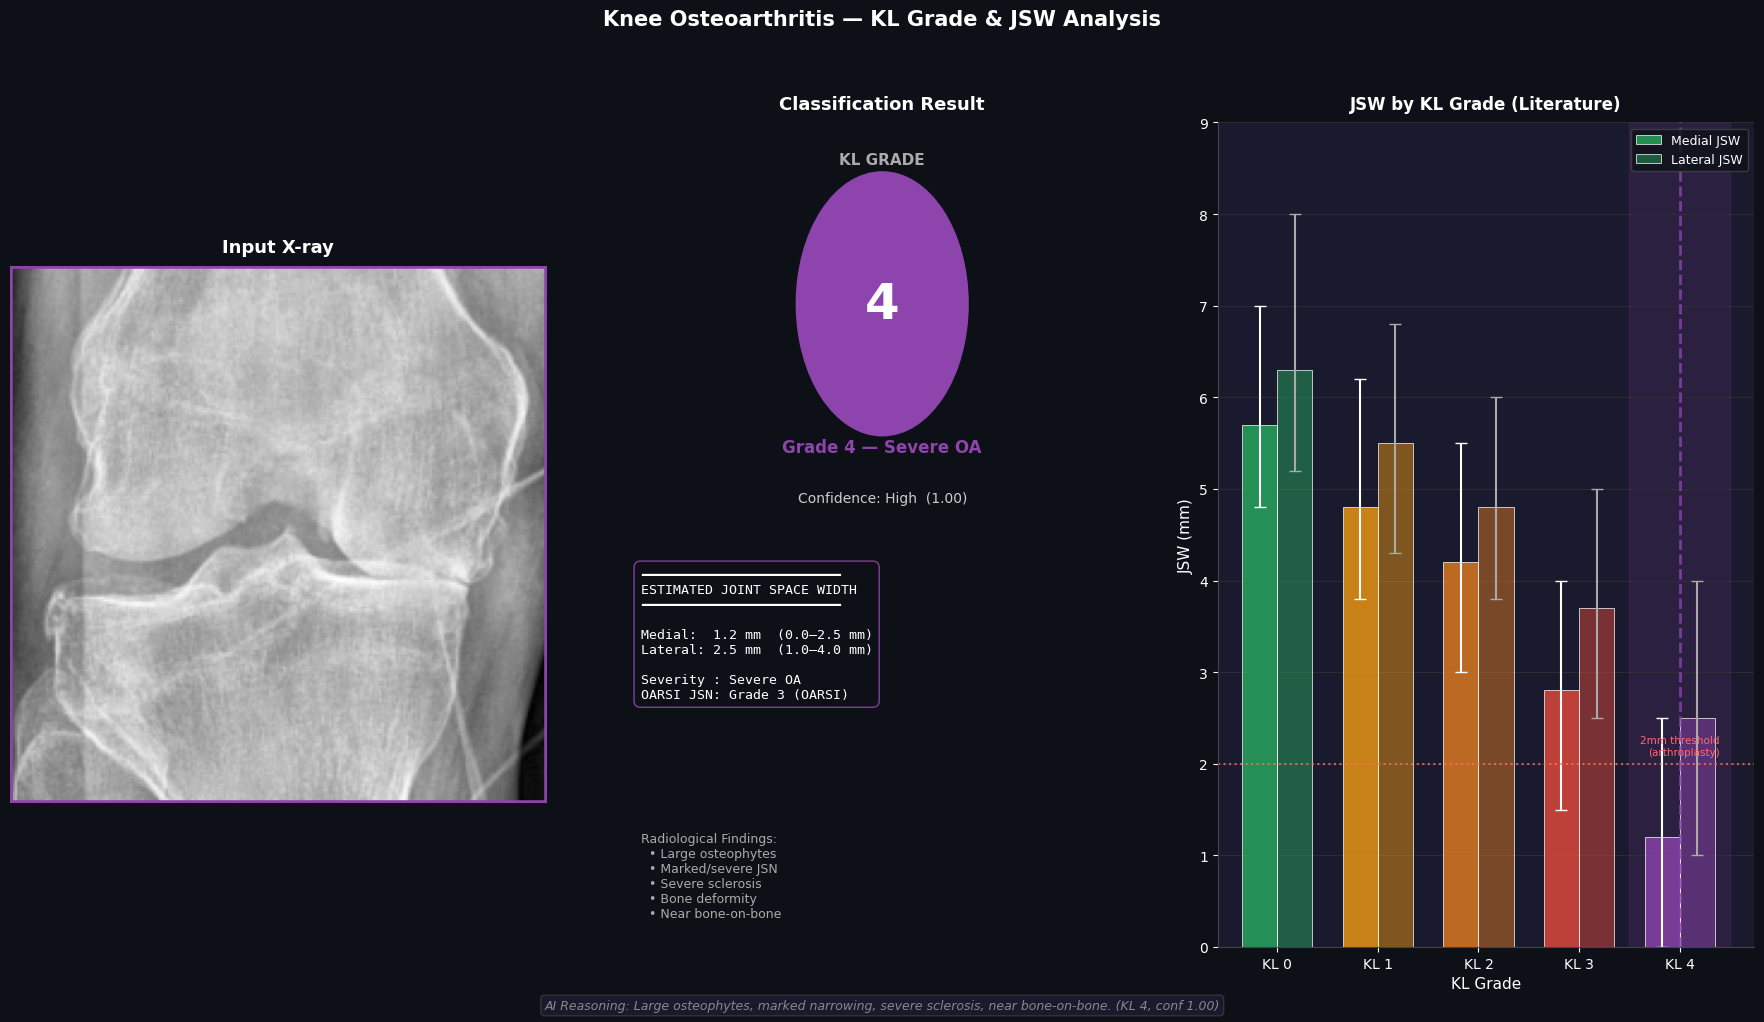

📊 Saved as 'kl_jsw_result.png'


In [ ]:
# ============================================================
# CELL 9: ▶ Run single image analysis
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import load_model

# Define TARGET_SIZE and load keras_model here
# This ensures they are available before analyze_knee_xray is called.
TARGET_SIZE = (224, 224) # Common input size for InceptionV3
MODEL_PATH = "/content/drive/MyDrive/inception_kl_model.h5" # Placeholder path, adjust if needed

try:
    keras_model = load_model(MODEL_PATH)
    print("✅ Keras model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model from {MODEL_PATH}: {e}")
    keras_model = None # Ensure keras_model is None if loading fails

IMAGE_PATH = "/content/drive/MyDrive/knee/Labeled/4/labeled_KL4_image10.png"

if keras_model:
    result = analyze_knee_xray(IMAGE_PATH)
else:
    print("Skipping analysis for a single image because the model could not be loaded.")


In [ ]:
# ============================================================
# CELL 10: ▶ Batch analysis (multiple images → CSV)
# ============================================================

def batch_analyze(image_paths: list) -> pd.DataFrame:
    records = []
    for i, path in enumerate(image_paths, 1):
        print(f"[{i}/{len(image_paths)}]  {Path(path).name}", end="  →  ")
        if not Path(path).exists():
            print("❌ not found")
            continue
        try:
            clf = classify_kl_grade_keras(path)
            kl  = clf.get("kl_grade", -1)
            jsw = get_jsw_estimate(kl) if kl >= 0 else {}
            print(f"KL {kl}  |  {clf.get('confidence','?')}  |  {jsw.get('severity','?')}")
            records.append({
                "Image":              Path(path).name,
                "KL_Grade":           kl,
                "Severity":           jsw.get("severity","N/A"),
                "Confidence":         clf.get("confidence","N/A"),
                "Conf_Score":         clf.get("confidence_score","N/A"),
                "Raw_Preds":          str(clf.get("raw_predictions",[])),
                "Medial_JSW_Mean_mm": jsw.get("medial_jsw_mm",{}).get("mean"),
                "Lateral_JSW_Mean_mm":jsw.get("lateral_jsw_mm",{}).get("mean"),
                "Osteophytes":        clf.get("osteophytes","N/A"),
                "JSN":                clf.get("joint_space_narrowing","N/A"),
                "Sclerosis":          clf.get("sclerosis","N/A"),
                "Bone_Deformity":     clf.get("bone_deformity","N/A"),
                "Reasoning":          clf.get("reasoning",""),
            })
        except Exception as e:
            print(f"❌  {e}")

    df = pd.DataFrame(records)
    if not df.empty:
        print("\n" + "═"*55)
        print(df[["Image","KL_Grade","Severity","Confidence","Medial_JSW_Mean_mm"]].to_string(index=False))
        df.to_csv("kl_jsw_batch_results.csv", index=False)
        print("\n💾 Saved → kl_jsw_batch_results.csv")
    return df


# ── Edit this list ───────────────────────────────────────────
image_list = [
    "/content/drive/MyDrive/ (4)jsw with kl fatsam data/KL grade (1)/test/0/9003316L.png",
    "/content/drive/MyDrive/ (4)jsw with kl fatsam data/KL grade (1)/test/0/9010308L.png",
    "/content/drive/MyDrive/ (4)jsw with kl fatsam data/KL grade (1)/test/0/9010308R.png",
]

df_results = batch_analyze(image_list)

[1/3]  9003316L.png  →  KL 2  |  Moderate  |  Mild OA
[2/3]  9010308L.png  →  KL 0  |  High  |  Normal
[3/3]  9010308R.png  →  KL 0  |  Moderate  |  Normal

═══════════════════════════════════════════════════════
       Image  KL_Grade Severity Confidence  Medial_JSW_Mean_mm
9003316L.png         2  Mild OA   Moderate                 4.2
9010308L.png         0   Normal       High                 5.7
9010308R.png         0   Normal   Moderate                 5.7

💾 Saved → kl_jsw_batch_results.csv


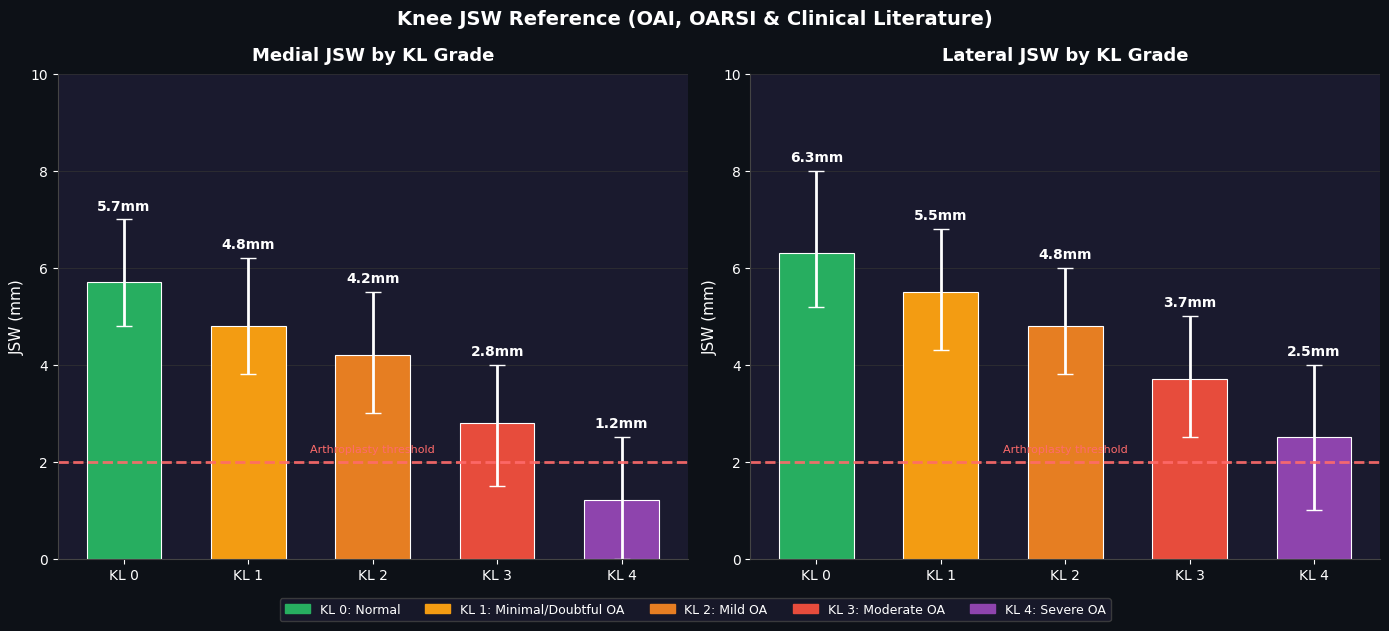

📊 Saved as 'jsw_reference_chart.png'


In [ ]:
# ============================================================
# CELL 11: ▶ Plot standalone JSW reference chart
# ============================================================
plot_jsw_reference_chart()